# A simple Maxent model

Here's an end-to-end example for fitting and applying a Maxent model.

This is to demonstrate the simplest pattern of model training. Full model training and evaluation should include creating train/test splits, cross-validation, feature selection, which aren't covered here.

The `elapid` sample data are occurrence records for *Ariolimax buttoni*, a species of banana slug native to coastal California, annotated with climate and vegetation data.

In [30]:
# packages
import elapid

import rasterio as rio
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn import metrics
import warnings

# paths
https = "https://earth-chris.github.io/images/research"
vector = f"{https}/ariolimax-buttoni.gpkg"
raster_names = [
    "ca-cloudcover-mean.tif",
    "ca-cloudcover-stdv.tif",
    "ca-leafareaindex-mean.tif",
    "ca-leafareaindex-stdv.tif",
    "ca-surfacetemp-mean.tif",
    "ca-surfacetemp-stdv.tif",
]
rasters = [f"{https}/{raster}" for raster in raster_names]
labels = [raster[3:-4] for raster in raster_names]

print(rasters[0])

# preferences
%matplotlib inline
mpl.style.use('ggplot')
warnings.filterwarnings("ignore")

print(f"Notebook last run with elapid version {elapid.__version__}")

https://earth-chris.github.io/images/research/ca-cloudcover-mean.tif
Notebook last run with elapid version 1.0.1


             species  year                        geometry
0  Ariolimax buttoni  2005  POINT (432271.994 4348048.850)
1  Ariolimax buttoni  2005  POINT (643606.559 4427302.366)
2  Ariolimax buttoni  2006  POINT (537588.166 4194012.740)
3  Ariolimax buttoni  2007  POINT (468489.994 4361538.275)
4  Ariolimax buttoni  2007  POINT (537466.797 4194096.065)
0     POINT (892500.000 3861500.000)
1     POINT (998500.000 4034500.000)
2    POINT (1150500.000 3797500.000)
3     POINT (673500.000 4008500.000)
4     POINT (938500.000 3956500.000)
dtype: geometry


<Axes: >

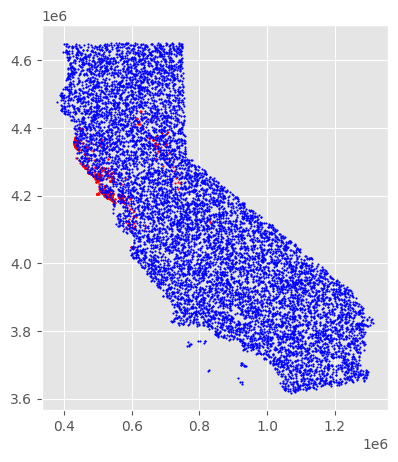

In [27]:
# read the presence data, draw background point samples
presence = gpd.read_file(vector)
background = elapid.sample_raster(rasters[0], count=10_000)

print(presence.head())
print(background.head())

# plot the presence data
plt.figure(figsize=(5,5))
presence.plot(markersize=1, color="red", ax=plt.gca())
background.plot(markersize=1, color="blue", ax=plt.gca())


In [34]:
# merge datasets and read the covariates at each point location
merged = elapid.stack_geodataframes(presence, background, add_class_label=True)
annotated = elapid.annotate(merged, rasters, drop_na=True, quiet=True)

merged.to_csv("merger.csv")
print(annotated.head())



                         geometry  class        b1        b2        b3  \
0  POINT (432271.994 4348048.850)      1  0.576870  0.494056  2.862292   
1  POINT (643606.559 4427302.366)      1  0.431535  0.495290  0.799059   
2  POINT (537588.166 4194012.740)      1  0.480075  0.499603  2.332337   
3  POINT (468489.994 4361538.275)      1  0.385041  0.486605  1.311130   
4  POINT (537466.797 4194096.065)      1  0.480075  0.499603  2.332337   

         b4         b5         b6  
0  1.365219  15.269872   4.438259  
1  0.660887  17.603615  13.115191  
2  0.828156  18.663361   5.532148  
3  0.646606  23.750160   9.557428  
4  0.828156  18.663361   5.532148  


In [18]:
# split the x/y data
x = annotated.drop(columns=['class', 'geometry'])
y = annotated['class']

# train the model
model = elapid.MaxentModel(transform='cloglog', beta_multiplier=2.0)
model.fit(x, y)

# evaluate training performance
ypred = model.predict(x)
auc = metrics.roc_auc_score(y, ypred)
print(f"Training AUC score: {auc:0.3f}")

# save the fitted model to disk
elapid.save_object(model, 'demo-maxent-model.ela')

model = elapid.load_object('demo-maxent-model.ela')

Training AUC score: 0.981


In [31]:
# partial dependence plots show how model predictions vary across the range of
# covariates

# Verifica la estructura de 'x' y 'labels'
print(x.head())
print(labels)

fig, ax = model.partial_dependence_plot(x, labels=labels, dpi=100)

         b1        b2        b3        b4         b5         b6
0  0.576870  0.494056  2.862292  1.365219  15.269872   4.438259
1  0.431535  0.495290  0.799059  0.660887  17.603615  13.115191
2  0.480075  0.499603  2.332337  0.828156  18.663361   5.532148
3  0.385041  0.486605  1.311130  0.646606  23.750160   9.557428
4  0.480075  0.499603  2.332337  0.828156  18.663361   5.532148
['cloudcover-mean', 'cloudcover-stdv', 'leafareaindex-mean', 'leafareaindex-stdv', 'surfacetemp-mean', 'surfacetemp-stdv']


KeyError: 'values'

In [20]:
# write the model predictions to disk
output_raster = 'demo-maxent-predictions.tif'
elapid.apply_model_to_rasters(model, rasters, output_raster, quiet=True)

# and read into memory
with rio.open(output_raster, 'r') as src:
    pred = src.read(1, masked=True)

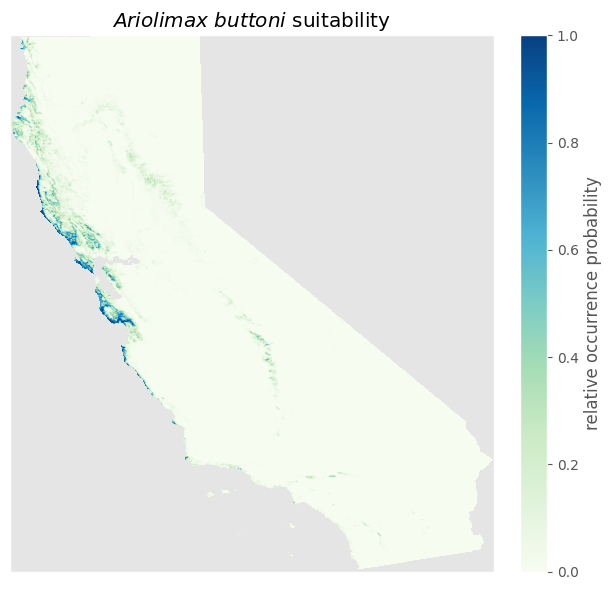

In [21]:
# plot the suitability predictions
fig, ax = plt.subplots(1, 1, figsize=(7, 6), dpi=100)
plot = ax.imshow(pred, vmin=0, vmax=1, cmap='GnBu')
ax.set_title('$Ariolimax\ buttoni$ suitability')
ax.set_xticks([])
ax.set_yticks([])
cbar = plt.colorbar(plot, ax=ax, label="relative occurrence probability", pad=0.04)
plt.tight_layout()